In [1]:
!pip install pandas_ta
!pip install yfinance

In [57]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup

In [58]:
def get_dynamic_sp500_tickers():
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36"
    }
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        raise Exception(f"Failed to fetch Wikipedia page. Status code: {response.status_code}")
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', {'id': 'constituents'})
    ticker_list = []
    for row in table.find_all('tr')[1:]:
        columns = row.find_all('td')
        if columns:
            ticker = columns[0].text.strip()
            ticker_clean = ticker.replace('.', '-')
            ticker_list.append(ticker_clean)
    return ticker_list

In [59]:
sp500_tickers = get_dynamic_sp500_tickers()

In [43]:
df_bulk = yf.download(tickers=sp500_tickers, start="1980-01-01", end="2023-12-31", group_by="ticker")

/tmp/ipykernel_973/3478295491.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bulk = yf.download(tickers=sp500_tickers, start="1980-01-01", end="2023-12-31", group_by="ticker")
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]  2 of 503 completed/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now

In [60]:
df_stacked = df_bulk.stack(level=0, future_stack=True).rename_axis(['Date', 'Ticker']).reset_index()
df_stacked = df_stacked.sort_values(by=['Date', 'Ticker'])
df_stacked.columns.name = None
df_stacked = df_stacked.set_index(['Date', 'Ticker'])

In [61]:
def calculate_features(group):
    # Group 1: pandas-ta features
    group.ta.rsi(length=14, append=True)
    group.ta.ppo(append=True)
    group.ta.obv(append=True)
    group.ta.atr(length=14, append=True)

    # Group 2: Custom Pandas Math
    group['Log_Return'] = np.log(group['Close'] / group['Close'].shift(1))
    group['Overnight_Gap'] = (group['Open'] - group['Close'].shift(1)) / group['Close'].shift(1)
    group['High_Low_Ratio'] = (group['High'] - group['Low']) / group['Close']

    return group

In [62]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df_stacked[numeric_cols] = df_stacked[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [63]:
if 'Adj Close' in df_stacked.columns:
    df_stacked = df_stacked.drop(columns=['Adj Close'])

# 2. Protect Date and Ticker in the index
if 'Ticker' in df_stacked.columns:
    df_stacked = df_stacked.set_index(['Date', 'Ticker'])
df_stacked = df_stacked.dropna()

In [64]:
df_stacked.head()

Open       High        Low      Close     Volume
Date       Ticker                                                       
1980-01-02 AEP      1.064612   1.072057   1.064612   1.064612    90000.0
           AIG     14.359092  14.359092  14.359092  14.359092        0.0
           APA      3.240803   3.240803   3.135124   3.135124    88358.0
           AVY      0.885894   0.892046   0.873590   0.873590   245600.0
           AXP      0.731408   0.737529   0.731408   0.731408  1755448.0

In [65]:
df_features = df_stacked.groupby(level='Ticker', group_keys=False).apply(calculate_features)
df_features = df_features.dropna().reset_index()

In [66]:
df_features.head()

,Date,Ticker,Open,High,Low,Close,Volume,RSI_14,PPO_12_26_9,PPOh_12_26_9,PPOs_12_26_9,OBV,ATRr_14,Log_Return,Overnight_Gap,High_Low_Ratio
0,1980-02-06,AEP,1.089637,1.097311,1.089637,1.089637,56100.0,57.366582,0.013359,0.0,0.013359,134900.0,0.015373,0.000000,0.000000e+00,0.007042
1,1980-02-06,AIG,14.359092,14.359092,14.359092,14.359092,0.0,41.639635,-0.457310,0.0,-0.457310,0.0,0.146027,0.008658,8.695904e-03,0.000000
2,1980-02-06,APA,3.369965,3.722226,3.369965,3.710484,188150.0,73.488155,2.436359,0.0,2.436359,-78482.0,0.127215,0.096260,4.042548e-07,0.094937
3,1980-02-06,AVY,1.082759,1.138127,1.082759,1.119671,304800.0,63.630023,6.349999,0.0,6.349999,3121600.0,0.032932,0.033522,-4.621684e-07,0.049451
4,1980-02-06,AXP,0.713046,0.713046,0.688564,0.703865,3304282.0,29.571537,-1.623971,0.0,-1.623971,-19699858.0,0.019037,-0.029981,-1.687742e-02,0.034783


In [67]:
# Restore the correct 5 macroeconomic benchmarks
benchmark_tickers = ['^TNX', '^IRX', '^VIX', 'DX-Y.NYB', 'XLK']

print("Downloading Macroeconomic Benchmarks...")
df_bench = yf.download(benchmark_tickers, start="1980-01-01", end="2023-12-31")['Close']

# Calculate Macro Features
df_macro = pd.DataFrame(index=df_bench.index)
df_macro['Term_Spread'] = df_bench['^TNX'] - df_bench['^IRX']
df_macro['VIX'] = df_bench['^VIX']
df_macro['USD_Index'] = df_bench['DX-Y.NYB']
df_macro['XLK_Log_Return'] = np.log(df_bench['XLK'] / df_bench['XLK'].shift(1))
df_macro = df_macro.dropna().reset_index()

# ==========================================
# 1. THE TUPLE CRUSHER (Flatten all columns)
# ==========================================
df_features.columns = [col[0] if isinstance(col, tuple) else col for col in df_features.columns]
df_macro.columns = [col[0] if isinstance(col, tuple) else col for col in df_macro.columns]

if isinstance(df_features.columns, pd.MultiIndex):
    df_features.columns = df_features.columns.get_level_values(0)

# ==========================================
# 2. THE DATE COLUMN FIX
# ==========================================
# Fix df_macro's Date Column
if 'Date' not in df_macro.columns:
    df_macro = df_macro.rename(columns={df_macro.columns[0]: 'Date'})

# Fix df_features' Date Column
if 'Ticker' not in df_features.columns:
    df_features = df_features.reset_index()
if 'Date' not in df_features.columns:
    df_features = df_features.rename(columns={df_features.columns[0]: 'Date'})

# Standardize Datetimes
df_features['Date'] = pd.to_datetime(df_features['Date']).dt.tz_localize(None)
df_macro['Date'] = pd.to_datetime(df_macro['Date']).dt.tz_localize(None)

# ==========================================
# 3. MERGING
# ==========================================
print("Merging Macro features into the main dataset...")
df_final = pd.merge(df_features, df_macro, on='Date', how='left')

df_final['Sector_Relative_Strength'] = df_final['Log_Return'] - df_final['XLK_Log_Return']
df_final = df_final.drop(columns=['XLK_Log_Return'])
df_final = df_final.sort_values(by=['Date', 'Ticker'])

print("\nSuccessfully Merged Data:")
print(df_final.head(5))

/tmp/ipykernel_973/3818644334.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download(benchmark_tickers, start="1980-01-01", end="2023-12-31")['Close']
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*******************   40%                       ]  2 of 5 completed/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  5 of 5 completed


Merging Macro features into the main dataset...

Successfully Merged Data:
        Date Ticker       Open       High        Low      Close     Volume  \
0 1980-02-06    AEP   1.089637   1.097311   1.089637   1.089637    56100.0   
1 1980-02-06    AIG  14.359092  14.359092  14.359092  14.359092        0.0   
2 1980-02-06    APA   3.369965   3.722226   3.369965   3.710484   188150.0   
3 1980-02-06    AVY   1.082759   1.138127   1.082759   1.119671   304800.0   
4 1980-02-06    AXP   0.713046   0.713046   0.688564   0.703865  3304282.0   

      RSI_14  PPO_12_26_9  PPOh_12_26_9  PPOs_12_26_9         OBV   ATRr_14  \
0  57.366582     0.013359           0.0      0.013359    134900.0  0.015373   
1  41.639635    -0.457310           0.0     -0.457310         0.0  0.146027   
2  73.488155     2.436359           0.0      2.436359    -78482.0  0.127215   
3  63.630023     6.349999           0.0      6.349999   3121600.0  0.032932   
4  29.571537    -1.623971           0.0     -1.623971 -196998

# First Model

In [79]:
features = [
    'RSI_14', 'PPO_12_26_9', 'PPOh_12_26_9', 'PPOs_12_26_9', 'OBV', 'ATRr_14',
    'Log_Return', 'Overnight_Gap', 'High_Low_Ratio', 'Term_Spread', 'VIX',
    'USD_Index', 'Sector_Relative_Strength'
]

# ==========================================
# 1. NEW TARGET: FIXING EXECUTION BIAS
# ==========================================
df_final = df_final.sort_values(by=['Date', 'Ticker'])

# We keep Next_Day_Return for the AI to learn general momentum
df_final['Next_Close'] = df_final.groupby('Ticker')['Close'].shift(-1)
df_final['Next_Day_Return'] = (df_final['Next_Close'] - df_final['Close']) / df_final['Close']

# REALITY CHECK: We evaluate using Actionable_Return (Tomorrow's Open to Tomorrow's Close)
df_final['Next_Open'] = df_final.groupby('Ticker')['Open'].shift(-1)
df_final['Actionable_Return'] = (df_final['Next_Close'] - df_final['Next_Open']) / df_final['Next_Open']

df_final = df_final.dropna()

# If tomorrow's return is greater than 0, target is 1. Otherwise, 0.
df_final['Target_Direction'] = (df_final['Next_Day_Return'] > 0).astype(int)

# ==========================================
# 2. PERFORM THE TIME-SERIES SPLIT
# ==========================================
split_date = '2010-01-01'
train_data = df_final[df_final['Date'] < split_date]
test_data  = df_final[df_final['Date'] >= split_date]

X_train = train_data[features]
y_train = train_data['Target_Direction']

X_test = test_data[features]
y_test = test_data['Next_Day_Return']

# ==========================================
# 3. TRAIN THE CLASSIFIER
# ==========================================
classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.5,
    colsample_bytree=0.5,
    random_state=42
)

print("Training XGBClassifier on Binary Targets...")
classifier.fit(X_train, y_train)

# ==========================================
# 4. PREDICT PROBABILITIES
# ==========================================
test_data_eval = test_data.copy()
test_data_eval['Predicted_Probability'] = classifier.predict_proba(X_test)[:, 1]

print("Training & Predictions Complete!")

Training XGBClassifier on Binary Targets...
Training & Predictions Complete!


<Figure size 1000x600 with 0 Axes>

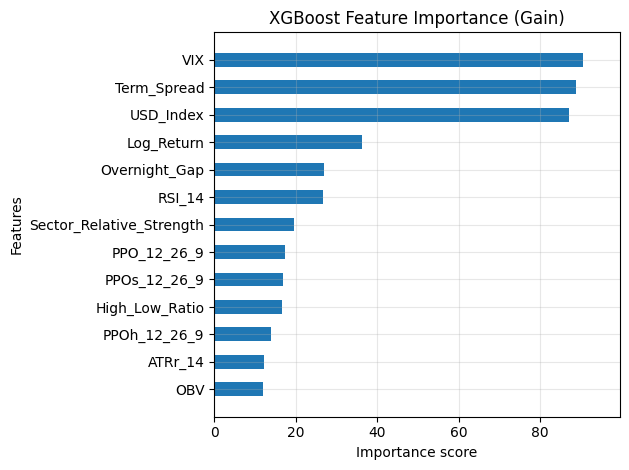


Exact Feature Importance Rankings:
                     Feature  Importance_Score
0                        VIX          0.194691
1                Term_Spread          0.191188
2                  USD_Index          0.187457
3                 Log_Return          0.077988
4              Overnight_Gap          0.058214
5                     RSI_14          0.057389
6   Sector_Relative_Strength          0.041871
7                PPO_12_26_9          0.037646
8               PPOs_12_26_9          0.036146
9             High_Low_Ratio          0.035597
10              PPOh_12_26_9          0.030026
11                   ATRr_14          0.026210
12                       OBV          0.025576


In [80]:
# ==========================================
# 1. VISUALIZE FEATURE IMPORTANCE
# ==========================================
plt.figure(figsize=(10, 6))

# We use importance_type='gain' because it measures the actual improvement in accuracy a feature brings
xgb.plot_importance(classifier, importance_type='gain', max_num_features=15, height=0.5, show_values=False)
plt.title('XGBoost Feature Importance (Gain)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 2. CREATE A CLEAN DATAFRAME
# ==========================================
# Extract the raw importance percentages
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance_Score': classifier.feature_importances_
})

# Sort them from most important to least important
importance_df = importance_df.sort_values(by='Importance_Score', ascending=False).reset_index(drop=True)

print("\nExact Feature Importance Rankings:")
print(importance_df)

In [81]:
# ==========================================
# 1. SET OUR WINNING PARAMETERS
# ==========================================
BEST_BUY = 0.50
BEST_SELL = 0.40
MAX_POSITIONS = 25

dates = sorted(test_data_eval['Date'].unique())

portfolio_weights = {} # ticker -> percentage of total portfolio
cash_weight = 1.0      # start 100% in cash

daily_returns_list = []
market_returns_list = []

print(f"Running REAL WORLD Optimized Backtest...")
print(f"Rules: Buy > {BEST_BUY} | Sell < {BEST_SELL} | Max Capacity: {MAX_POSITIONS} Stocks")
print(f"Execution: Open-to-Close Returns | Rebalancing: Quarterly\n")

# ==========================================
# 2. RUN THE DAILY BACKTEST
# ==========================================
for i, date in enumerate(dates):
    day_data = test_data_eval[test_data_eval['Date'] == date]
    prob_dict = dict(zip(day_data['Ticker'], day_data['Predicted_Probability']))

    # WE NOW USE ACTIONABLE RETURN! (Open-to-Close)
    ret_dict = dict(zip(day_data['Ticker'], day_data['Actionable_Return']))

    # --- 1. SELL LOGIC ---
    tickers_to_remove = []
    for ticker in portfolio_weights.keys():
        if ticker not in prob_dict or prob_dict[ticker] < BEST_SELL:
            tickers_to_remove.append(ticker)

    for ticker in tickers_to_remove:
        cash_weight += portfolio_weights[ticker]
        del portfolio_weights[ticker]

    # --- 2. BUY LOGIC ---
    open_slots = MAX_POSITIONS - len(portfolio_weights)
    if open_slots > 0:
        candidates = day_data[
            (day_data['Predicted_Probability'] > BEST_BUY) &
            (~day_data['Ticker'].isin(portfolio_weights.keys()))
        ]
        candidates = candidates.sort_values(by='Predicted_Probability', ascending=False)
        top_candidates = candidates.head(open_slots)['Ticker'].tolist()

        for ticker in top_candidates:
            target_weight = 1.0 / MAX_POSITIONS
            actual_buy_weight = min(target_weight, cash_weight)

            if actual_buy_weight > 0:
                portfolio_weights[ticker] = actual_buy_weight
                cash_weight -= actual_buy_weight

    # --- 3. CALCULATE PORTFOLIO RETURN ---
    daily_portfolio_return = 0.0

    for ticker, weight in portfolio_weights.items():
        stock_return = ret_dict.get(ticker, 0.0)
        daily_portfolio_return += weight * stock_return

    daily_returns_list.append(daily_portfolio_return)

    # Market Baseline also now uses Actionable_Return for an apples-to-apples comparison!
    market_returns_list.append(day_data['Actionable_Return'].mean())

    # --- 4. DRIFT THE WEIGHTS ---
    portfolio_growth = 1.0 + daily_portfolio_return

    for ticker in portfolio_weights.keys():
        stock_return = ret_dict.get(ticker, 0.0)
        portfolio_weights[ticker] = (portfolio_weights[ticker] * (1.0 + stock_return)) / portfolio_growth

    cash_weight = cash_weight / portfolio_growth

    # --- 5. QUARTERLY REBALANCING ---
    # Trigger a rebalance on the very first trading day of Jan, Apr, Jul, Oct
    current_month = date.month
    previous_month = dates[i-1].month if i > 0 else date.month

    if current_month in [1, 4, 7, 10] and previous_month in [12, 3, 6, 9]:
        total_portfolio_value = cash_weight + sum(portfolio_weights.values())
        held_count = len(portfolio_weights)

        if held_count > 0:
            rebalanced_weight = (total_portfolio_value - cash_weight) / held_count
            for ticker in portfolio_weights.keys():
                portfolio_weights[ticker] = rebalanced_weight

# ==========================================
# 3. TIME-SERIES AGGREGATION (SEMI-ANNUAL)
# ==========================================
df_returns = pd.DataFrame({
    'Date': dates,
    'AI_Strategy': daily_returns_list,
    'Market_Baseline': market_returns_list
})

df_returns['Date'] = pd.to_datetime(df_returns['Date'])
df_returns.set_index('Date', inplace=True)

def compound_return(series):
    return (np.prod(1 + series) - 1) * 100

df_returns['Year'] = df_returns.index.year
df_returns['Half'] = np.where(df_returns.index.month <= 6, 'H1', 'H2')
df_returns['SemiAnnual_Label'] = df_returns['Year'].astype(str) + " " + df_returns['Half']

annual_returns = df_returns.groupby('Year')[['AI_Strategy', 'Market_Baseline']].agg(compound_return)
semiannual_returns = df_returns.groupby('SemiAnnual_Label')[['AI_Strategy', 'Market_Baseline']].agg(compound_return)

# ==========================================
# 4. PRINT THE REPORTS
# ==========================================
print("="*55)
print("📊 SEMI-ANNUAL PERFORMANCE REPORT (6-Month Blocks) 📊")
print("="*55)
print(f"{'Period':<15} | {'AI Strategy':<15} | {'Market Baseline':<15}")
print("-" * 55)
for period, row in semiannual_returns.iterrows():
    print(f"{period:<15} | {row['AI_Strategy']:>14.2f}% | {row['Market_Baseline']:>14.2f}%")

total_ai = compound_return(df_returns['AI_Strategy'])
total_market = compound_return(df_returns['Market_Baseline'])

print("\n" + "="*55)
print(f"TOTAL COMPOUNDED:  AI = {total_ai:.2f}%  |  MARKET = {total_market:.2f}%")
print("="*55)

Running REAL WORLD Optimized Backtest...
Rules: Buy > 0.5 | Sell < 0.4 | Max Capacity: 25 Stocks
Execution: Open-to-Close Returns | Rebalancing: Quarterly

📊 SEMI-ANNUAL PERFORMANCE REPORT (6-Month Blocks) 📊
Period          | AI Strategy     | Market Baseline
-------------------------------------------------------
2010 H1         |           5.33% |          -2.16%
2010 H2         |          16.59% |          19.21%
2011 H1         |           7.78% |           6.39%
2011 H2         |          -0.15% |          -7.50%
2012 H1         |          11.00% |          11.50%
2012 H2         |           5.37% |           6.64%
2013 H1         |          14.78% |          10.46%
2013 H2         |           7.01% |           8.72%
2014 H1         |          -1.29% |           2.60%
2014 H2         |           6.81% |           2.62%
2015 H1         |           1.64% |           2.70%
2015 H2         |           4.65% |           0.56%
2016 H1         |          20.34% |          19.62%
2016 H2 